# Feature Selection

## Import Packages

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

## Read In Data

In [39]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(-1,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(-1,)

In [40]:
demo_cols = sorted(['age', 'sex'])
blood_test_cols = sorted(['TSH', 'T3', 'TT4', 'T4U', 'FTI'])
med_hist_cols = sorted(['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych'])
data_flag_cols = sorted(['TSH_missing', 'T3_missing', 'TT4_missing', 'T4U_missing', 'FTI_missing', 'sex_missing'])
label_cols = sorted(['antithyroid treatment', 'binding protein', 'discordant results', 'general health', 'hyperthyroid conditions', 'hypothyroid conditions', 'miscellaneous', 'negative', 'replacement therapy'])

In [41]:
dis_cols = [X_train.columns.to_list().index(col) for col in demo_cols + med_hist_cols + data_flag_cols]

## Calculate Mutual Information

In [44]:
imputer = KNNImputer()

X_train_imp = imputer.fit_transform(X_train)

mut_info = mutual_info_classif(X_train_imp, y_train, discrete_features=dis_cols, random_state=6740)

d:\Programs\Python3.13\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


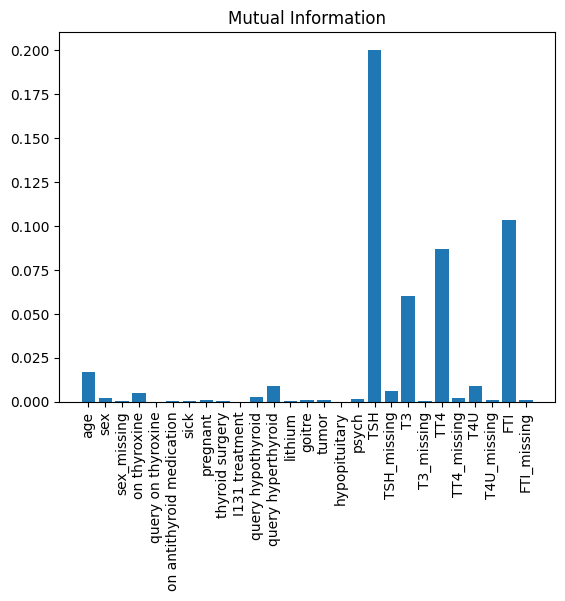

In [45]:
plt.bar(range(len(mut_info)), mut_info)
plt.xticks(range(len(mut_info)), X_train.columns, rotation=90)
plt.title('Mutual Information')
plt.show()